# Random Forest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path('..').resolve()))

from src.utils.paths import PROCESSED_DIR, RESULTS_DIR, setup_plotting, ensure_dirs
from src.data.preprocessing import prepare_data
from src.training.random_forest import train_rf_with_cv

setup_plotting()
ensure_dirs()

## Load Datasets

In [2]:
dataset_A = pd.read_csv(PROCESSED_DIR / 'dataset_A_full.csv')
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
dataset_C = pd.read_csv(PROCESSED_DIR / 'dataset_C_transcriptomics.csv')

print("Dataset shapes:")
print(f"  A (Full): {dataset_A.shape}")
print(f"  B (Metabolomics): {dataset_B.shape}")
print(f"  C (Transcriptomics): {dataset_C.shape}")

Dataset shapes:
  A (Full): (33, 1176)
  B (Metabolomics): (79, 206)
  C (Transcriptomics): (31, 212)


In [3]:

X_A, y_A, features_A = prepare_data(dataset_A, "Dataset A")
X_B, y_B, features_B = prepare_data(dataset_B, "Dataset B")
X_C, y_C, features_C = prepare_data(dataset_C, "Dataset C")


Dataset A: 33 samples, 1169 features

Dataset B: 79 samples, 199 features

Dataset C: 31 samples, 205 features


## Train on All Datasets

In [4]:
print("="*60)
print("DATASET A: Full")
print("="*60)
results_A = train_rf_with_cv(X_A, y_A, features_A)

print("\n" + "="*60)
print("DATASET B: Metabolomics")
print("="*60)
results_B = train_rf_with_cv(X_B, y_B, features_B)

print("\n" + "="*60)
print("DATASET C: Transcriptomics")
print("="*60)
results_C = train_rf_with_cv(X_C, y_C, features_C)

DATASET A: Full
Training 5-fold CV (Imputation & Selection INSIDE folds)...


  Fold 1: R²=-0.756, RMSE=3.860, MAE=3.650


  Fold 2: R²=-0.008, RMSE=5.471, MAE=4.593


  Fold 3: R²=-0.292, RMSE=4.906, MAE=4.288


  Fold 4: R²=-0.365, RMSE=5.172, MAE=3.723


...

  Fold 1: R²=0.344, RMSE=3.873, MAE=2.683


  Fold 2: R²=0.531, RMSE=2.692, MAE=2.236


  Fold 3: R²=-0.332, RMSE=4.402, MAE=3.309


  Fold 4: R²=0.193, RMSE=1.910, MAE=1.426


  Fold 5: R²=0.519, RMSE=3.912, MAE=2.817

Final R² = 0.251 ± 0.354


## Results Summary

In [5]:
summary = pd.DataFrame([
    {'Dataset': 'A (Full)', 'N': len(X_A), 'Features': X_A.shape[1],
     'R²': f"{results_A['mean_r2']:.3f} ± {results_A['std_r2']:.3f}",
     'RMSE': f"{results_A['mean_rmse']:.3f} ± {results_A['std_rmse']:.3f}",
     'MAE': f"{results_A['mean_mae']:.3f} ± {results_A['std_mae']:.3f}"},
    {'Dataset': 'B (Metabolomics)', 'N': len(X_B), 'Features': X_B.shape[1],
     'R²': f"{results_B['mean_r2']:.3f} ± {results_B['std_r2']:.3f}",
     'RMSE': f"{results_B['mean_rmse']:.3f} ± {results_B['std_rmse']:.3f}",
     'MAE': f"{results_B['mean_mae']:.3f} ± {results_B['std_mae']:.3f}"},
    {'Dataset': 'C (Transcriptomics)', 'N': len(X_C), 'Features': X_C.shape[1],
     'R²': f"{results_C['mean_r2']:.3f} ± {results_C['std_r2']:.3f}",
     'RMSE': f"{results_C['mean_rmse']:.3f} ± {results_C['std_rmse']:.3f}",
     'MAE': f"{results_C['mean_mae']:.3f} ± {results_C['std_mae']:.3f}"}
])

print("\nRESULTS SUMMARY:")
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / 'rf_summary.csv', index=False)


RESULTS SUMMARY:
            Dataset  N  Features             R²          RMSE           MAE
           A (Full) 33      1169 -0.626 ± 0.661 4.491 ± 1.010 3.774 ± 0.757
   B (Metabolomics) 79       199  0.129 ± 0.149 3.618 ± 0.508 2.859 ± 0.339
C (Transcriptomics) 31       205  0.251 ± 0.354 3.358 ± 1.025 2.494 ± 0.709


## Visualizations

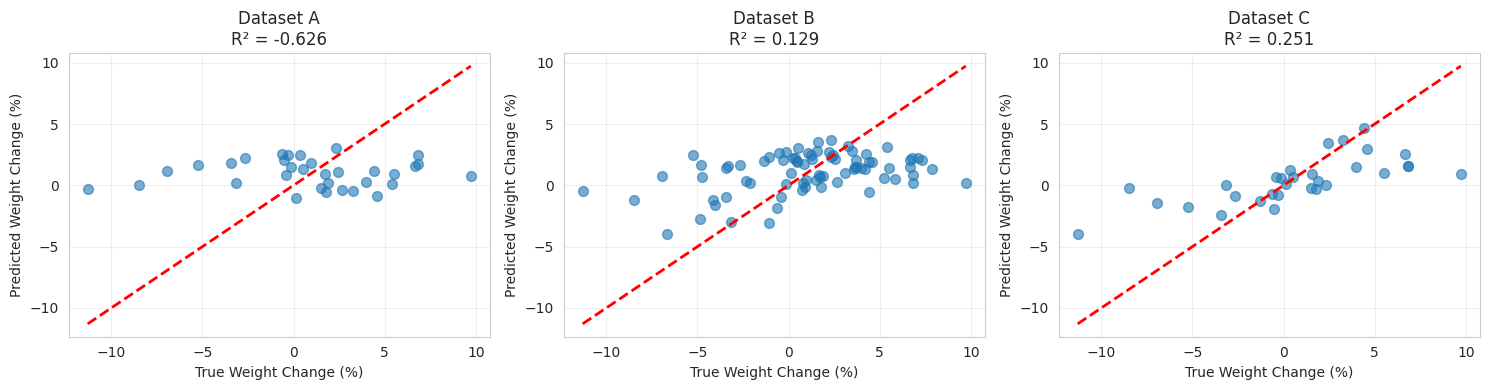

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, results, name in zip(axes, [results_A, results_B, results_C], ['Dataset A', 'Dataset B', 'Dataset C']):
    ax.scatter(results['y_true'], results['y_pred'], alpha=0.6, s=50)
    min_val = min(results['y_true'].min(), results['y_pred'].min())
    max_val = max(results['y_true'].max(), results['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_xlabel('True Weight Change (%)')
    ax.set_ylabel('Predicted Weight Change (%)')
    ax.set_title(f'{name}\nR² = {results["mean_r2"]:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rf_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Results

In [7]:
rf_results = {'dataset_A': results_A, 'dataset_B': results_B, 'dataset_C': results_C, 'summary': summary}
with open(RESULTS_DIR / 'rf_results.pkl', 'wb') as f:
    pickle.dump(rf_results, f)
print("Results saved to", RESULTS_DIR)

Results saved to /home/bendavison/PycharmProjects/msc_dissertation/results
